In [1]:
import copy
import random
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from UQpy.distributions import Normal, Uniform, JointIndependent
import SAPCE

In [2]:
# --------------------------------------------------
# Nastavení
# --------------------------------------------------
DATA_FILE = "Oakwood_NVM.csv"
SEED = 1
TEST_SIZE = 300
nsim = np.arange(15, 120, 10)

degree_list = [1, 2, 3, 5, 7, 10]
cond_list = [10, 25, 50, 100, 250, 500, 1000]
cr_list = [1e-8, 1e-6, 1e-4, 1e-3]
ratio_list = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]


In [3]:
# --------------------------------------------------
# Data
# --------------------------------------------------
data = pd.read_csv(DATA_FILE, sep=";", header=0)

for col in data.columns:
    if data[col].dtype == object:
        data[col] = pd.to_numeric(
            data[col].astype(str).str.replace(",", ".", regex=False),
            errors="raise"
        )

arr = data.to_numpy()
X = arr[:, :12]
Y_N = arr[:, 12:]

n_inputs = X.shape[1]
linear_terms = n_inputs + 1



In [4]:
# --------------------------------------------------
# Rozdělení vstupů
# --------------------------------------------------
marg = [
    Normal(13, 1),
    Uniform(30, 40),
    Uniform(2, 1),
    Normal(65, 5),
    Normal(30, 5),
    Normal(30, 1),
    Uniform(0.6, 0.5),
    Uniform(2, 1),
    Normal(130, 10),
    Normal(5, 1),
    Normal(42, 1),
    Uniform(0.45, 0.2)
]

joint = JointIndependent(marginals=marg)

In [5]:

# --------------------------------------------------
# Pomocné funkce
# --------------------------------------------------

# Funkce určí maximální povolený poměr počtu členů báze vůči počtu trénovacích bodů.
# Vstup:
#   n_train ... počet trénovacích bodů
# Výstup:
#  maximální povolený ratio limit
def max_ratio_for_n(n_train):
    min_ratio = (linear_terms + 0.5) / n_train

    if n_train < 30:
        base = 0.90
    elif n_train < 60:
        base = 0.70
    elif n_train < 100:
        base = 0.55
    elif n_train < 200:
        base = 0.60
    else:
        base = 0.70

    return min(0.95, max(base, min_ratio))


#  vybere vhodné hodnoty ratio_limit pro daný počet trénovacích bodů.
# Bere jen takové hodnoty z ratio_list, které nepřekročí povolený horní limit
# Vstup:
#   n_train ... počet trénovacích bodů
# Výstup:
#   seřazený seznam použitelných hodnot ratio_limit
def ratio_candidates(n_train):
    upper = max_ratio_for_n(n_train)

    out = [
        r for r in ratio_list
        if r <= upper and int(np.floor(r * n_train)) >= linear_terms
    ]

    if len(out) == 0:
        out = [min(0.95, (linear_terms + 0.5) / n_train)]

    if not any(np.isclose(upper, r) for r in out):
        if int(np.floor(upper * n_train)) >= linear_terms:
            out.append(upper)

    return sorted(out)


# najde funkci admissible_neighbors z knihovny SAPCE.
# Výstup:
#   funkce admissible_neighbors
def admissible_neighbors_fn():
    if hasattr(SAPCE, "admissible_neighbors"):
        return SAPCE.admissible_neighbors

    glb = SAPCE.SensitivityAdaptivePCE.construct_adaptive_basis.__globals__

    if "admissible_neighbors" in glb:
        return glb["admissible_neighbors"]

    raise RuntimeError("admissible_neighbors not found")


# Funkce filtruje multi-indexy podle zadaného maximálního stupně.
# Nechá jen ty indexy, kde součet indexu není větší než degree
# Vstup:
#   indices ... seznam multi-indexů
#   degree ... maximální povolený stupeň polynomu
# Výstup:
#   filtrovaný seznam multi-indexů
def filter_indices(indices, degree):
    out = []

    for idx in indices:
        idx = np.asarray(idx, dtype=int)

        if np.sum(idx) <= degree and np.all(idx <= degree):
            out.append(idx.tolist())

    return out


# funkce postupně rozšiřuje adaptivní bázi SAPCE, ale hlídá omezení.
def adaptive_basis_rollback(sapce, cond_limit, ratio_limit):
    neigh = admissible_neighbors_fn()
    n_train = sapce.exp_design_in.shape[0]
    max_terms = int(np.floor(ratio_limit * n_train))

    while True:
        terms = len(sapce.pce.multi_index_set)

        if terms >= n_train:
            return "basis_ge_n_train"

        if terms >= max_terms:
            return "basis_ge_ratio"

        if sapce.condition_number > cond_limit:
            return "condition_too_large"

        new_idx = neigh(
            sapce.active_multi_indices[-1],
            sapce.active_multi_indices
        )

        new_idx = filter_indices(new_idx, sapce.max_partial_degree)

        if len(new_idx) == 0:
            return "no_new_indices"

        proposed_terms = (
            len(sapce.active_multi_indices)
            + len(sapce.admissible_multi_indices)
            + len(new_idx)
        )

        if proposed_terms >= n_train:
            return "proposed_ge_n_train"

        if proposed_terms > max_terms:
            return "proposed_ge_ratio"

        old_active = copy.deepcopy(sapce.active_multi_indices)
        old_admissible = copy.deepcopy(sapce.admissible_multi_indices)
        old_multi = copy.deepcopy(sapce.pce.multi_index_set)

        sapce.admissible_multi_indices += new_idx
        sapce.set_multi_index_set(
            sapce.active_multi_indices + sapce.admissible_multi_indices
        )
        sapce.compute_coefficients()

        if sapce.condition_number > cond_limit:
            sapce.active_multi_indices = old_active
            sapce.admissible_multi_indices = old_admissible
            sapce.set_multi_index_set(old_multi)
            sapce.compute_coefficients()

            return "rollback"

        i0 = len(sapce.active_multi_indices)
        coef = np.asarray(sapce.pce.coefficients[i0:])

        if coef.size == 0:
            return "no_coefficients"

        if coef.ndim == 1:
            score = np.abs(coef)
        else:
            score = np.sum(np.abs(coef), axis=1)

        best = int(np.argmax(score))
        sapce.active_multi_indices.append(
            sapce.admissible_multi_indices.pop(best)
        )


# vytvoří náhodné rozdělení dat na testovací indexy a trénovací pool.
# Výstup:
#   test_idx ... seznam testovacích indexů
#   train_pool ... seznam indexů pro trénování
def make_split(n_total, test_size, max_train_size, seed):
    rng = random.Random(seed)
    idx = list(range(n_total))
    rng.shuffle(idx)

    test_idx = idx[:test_size]
    train_pool = idx[test_size:test_size + max_train_size]

    return test_idx, train_pool


# Funkce rozdělí vstupní a výstupní data podle zadaných indexů.
def split_data(X, Y, train_idx, test_idx):
    train_idx = np.asarray(train_idx, dtype=int)
    test_idx = np.asarray(test_idx, dtype=int)

    return X[train_idx], Y[train_idx], X[test_idx], Y[test_idx]


# natrénuje jeden SAPCE/PCE model pro jednu konkrétní kombinaci parametrů.
def fit_one_config(Xtr, Ytr, Xte, Yte, degree, cond_limit, ratio_limit, cr):
    sapce = SAPCE.SensitivityAdaptivePCE(
        pdf=joint,
        exp_design_in=Xtr,
        exp_design_out=Ytr,
        max_partial_degree=degree,
        num_inputs=12
    )

    status = adaptive_basis_rollback(sapce, cond_limit, ratio_limit)

    terms_before = len(sapce.pce.multi_index_set)
    sapce.construct_pruned_pce(cr=cr)
    terms_after = len(sapce.pce.multi_index_set)

    err = np.asarray(sapce.pce.validation_error(Xte, Yte)).ravel()

    cond = float(sapce.condition_number)
    terms = len(sapce.pce.multi_index_set)
    ratio = terms / Xtr.shape[0]

    valid = (
        np.all(np.isfinite(err))
        and np.all(err >= 0)
        and cond <= cond_limit
        and terms < Xtr.shape[0]
        and ratio <= ratio_limit
    )

    return {
        "degree": degree,
        "cond_limit": cond_limit,
        "ratio_limit": ratio_limit,
        "cr": cr,
        "err": err,
        "mean": float(np.mean(err)),
        "median": float(np.median(err)),
        "max": float(np.max(err)),
        "cond": cond,
        "terms": terms,
        "ratio": ratio,
        "removed": terms_before - terms_after,
        "status": status,
        "valid": valid
    }


# Funkce projde všechny kombinace parametrů z degree_list, cond_list,
# Výstup:
#   best ... nejlepší nalezená konfigurace, nebo None pokud žádná není validní
#   results ... seznam všech otestovaných konfigurací
def find_best_config(Xtr, Ytr, Xte, Yte, n_train):
    results = []

    for degree in degree_list:
        for cond_limit in cond_list:
            for ratio_limit in ratio_candidates(n_train):
                for cr in cr_list:
                    try:
                        results.append(
                            fit_one_config(
                                Xtr, Ytr, Xte, Yte,
                                degree, cond_limit, ratio_limit, cr
                            )
                        )
                    except Exception:
                        pass

    valid = [r for r in results if r["valid"]]

    if len(valid) == 0:
        return None, results

    def score(r):
        return (
            r["mean"]
            + 1e-5 * r["ratio"]
            + 1e-8 * np.log10(r["cond"] + 1.0)
        )

    return min(valid, key=score), results

In [6]:
# --------------------------------------------------
# Výpočet
# --------------------------------------------------
test_idx, train_pool = make_split(
    n_total=X.shape[0],
    test_size=TEST_SIZE,
    max_train_size=int(np.max(nsim)),
    seed=SEED
)

errs = np.full((len(nsim), Y_N.shape[1]), np.nan)
rows = []

for i, n_train in enumerate(nsim):
    train_idx = train_pool[:n_train]
    Xtr, Ytr, Xte, Yte = split_data(X, Y_N, train_idx, test_idx)

    best, all_results = find_best_config(Xtr, Ytr, Xte, Yte, n_train)

    if best is None:
        continue

    errs[i, :] = best["err"]

    rows.append({
        "n_train": n_train,
        "mean": best["mean"],
        "median": best["median"],
        "max": best["max"],
        "condition": best["cond"],
        "basis_terms": best["terms"],
        "basis_ratio": best["ratio"],
        "degree": best["degree"],
        "cond_limit": best["cond_limit"],
        "ratio_limit": best["ratio_limit"],
        "cr": best["cr"],
        "valid_models": sum(r["valid"] for r in all_results),
        "tested_models": len(all_results)
    })

res = pd.DataFrame(rows)

overlap = len(set(test_idx).intersection(set(train_pool)))


X: (1000, 12) | Y_N: (1000, 339) | train/test overlap: 0
 n_train     mean   median       max  condition  basis_terms  basis_ratio  degree  cond_limit  ratio_limit           cr  valid_models  tested_models
      15 0.930012 0.200607 26.372005  42.317512           13     0.866667       1          50          0.9 1.000000e-08           120            168
      25 0.026412 0.017580  0.365456  11.365433           19     0.760000       2          25          0.8 1.000000e-08           672            672
      35 0.022682 0.013350  0.320251   5.110590           16     0.457143       2          10          0.5 1.000000e-08           672            672
      45 0.011272 0.006297  0.303546   8.878524           30     0.666667       3          10          0.7 1.000000e-08           840            840
      55 0.010100 0.005428  0.319054   7.540609           30     0.545455       3          10          0.6 1.000000e-08           840            840
      65 0.008625 0.004970  0.232611   6.261033  

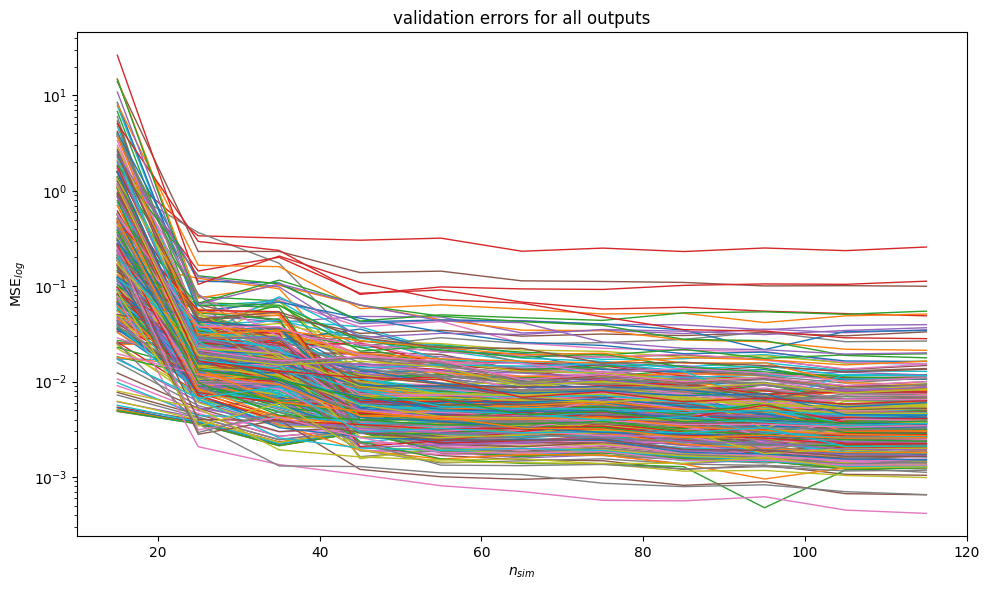

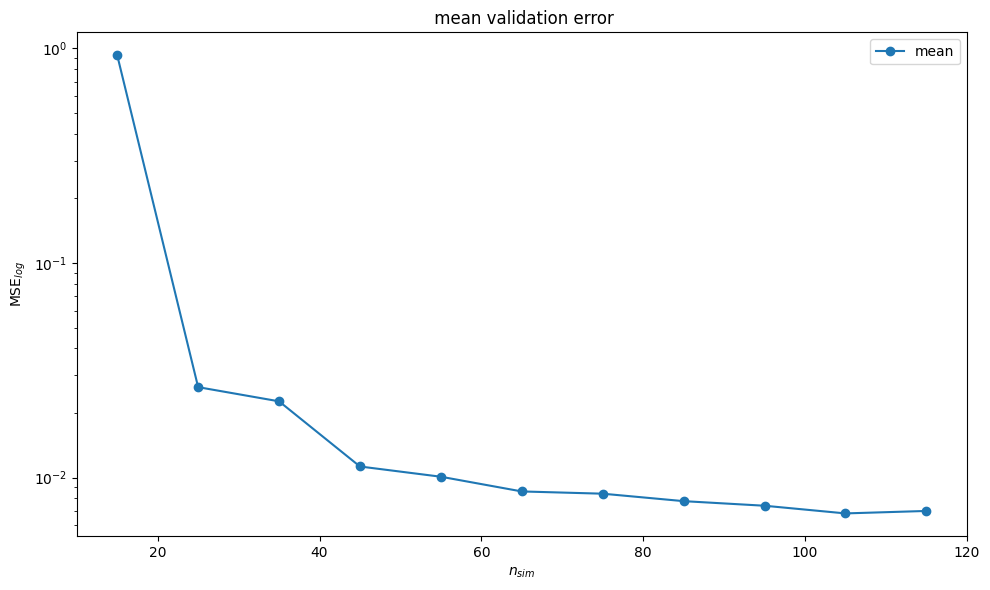

In [7]:

# --------------------------------------------------
# Graf 1: všechny raw výstupní křivky
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(errs.shape[1]):
    ax.plot(nsim, errs[:, i], linewidth=1)

ax.set_yscale("log")
ax.set_ylabel("MSE$_{log}$")
ax.set_xlabel("$n_{sim}$")
ax.set_title("validation errors for all outputs")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Graf 2: pouze raw mean
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(res["n_train"], res["mean"], marker="o", label="mean")

ax.set_yscale("log")
ax.set_ylabel("MSE$_{log}$")
ax.set_xlabel("$n_{sim}$")
ax.set_title(" mean validation error")
ax.legend()
plt.tight_layout()
plt.show()